In [1]:
from networkx.algorithms.approximation import metric_closure
from sklearn import preprocessing
from data.FlagsRegression.dataset import load_dataset
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import fclusterdata
import pickle
import matplotlib
from sklearn.metrics.pairwise import pairwise_distances
import time
import networkx as nx
from data.FlagsRegression.dataset import DatasetGenerator
from tqdm import tqdm
from os import path
import glob

In [2]:
saved_results_path = '/home/dsalami/projects/FedGen/data/FlagsRegression/ApproachComparison/lookback_{lookback}/steps_{steps}/{approach}/{model}/rep_{rep}'
HYPER_PARAMETERS = {
    'model': ['lstm', 'cnn'],
    'approach': ['Isolated', 'Centralized', 'FedAvg', 'FedGen'],
    'repetition': [10, 1, 1, 1],
    'lookback': [60],
    'step': [1, 5, 15, 30],
}
results = pd.DataFrame([], columns=['lookback', 'step', 'approach', 'model', 'repetition',
                                    'mse_avg', 'mse_std',
                                    'unscaled_mse_avg', 'unscaled_mse_std',
                                    'mape_avg', 'mape_std',
                                    'unscaled_mape_avg', 'unscaled_mape_std',
                                    'mae_avg', 'mae_std',
                                    'unscaled_mae_avg', 'unscaled_mae_std'])

In [3]:
for LOOKBACK_KEY, LOOKBACK in enumerate(HYPER_PARAMETERS['lookback']):
    for STEP_KEY, STEP in enumerate(HYPER_PARAMETERS['step']):
        for MODEL_KEY, MODEL in enumerate(HYPER_PARAMETERS['model']):
            for APPROACH_KEY, APPROACH in enumerate(HYPER_PARAMETERS['approach']):
                for REPETITION in range(HYPER_PARAMETERS['repetition'][APPROACH_KEY]):
                    saved_result_path = saved_results_path.format(
                        lookback=LOOKBACK,
                        steps=STEP,
                        approach=APPROACH,
                        model=MODEL,
                        rep=REPETITION
                    )
                    saved_result_path = path.join(saved_result_path, '*.pkl')
                    if len(glob.glob(saved_result_path)) == 0:
                        print(saved_result_path)
                    saved_result_path = glob.glob(saved_result_path)[0]
                    with open(saved_result_path, 'rb') as f:
                        x = pickle.load(f)
                        metrics = x['glob_test_metric'][:5]
                        #metrics = [sorted(metrics, key=lambda x: x['unscaled_mae'])[0]]
                        data_to_be_inserted = {
                            'lookback': LOOKBACK,
                            'step': STEP,
                            'approach': APPROACH,
                            'model': MODEL,
                            'repetition': REPETITION,
                            'mse_avg': np.mean([metric['mse'] for metric in metrics]),
                            'mse_std': np.std([metric['mse'] for metric in metrics]),
                            'unscaled_mse_avg': np.mean([metric['unscaled_mse'] for metric in metrics]),
                            'unscaled_mse_std': np.std([metric['unscaled_mse'] for metric in metrics]),
                            'mape_avg': np.mean([metric['mape'] for metric in metrics]),
                            'mape_std': np.std([metric['mape'] for metric in metrics]),
                            'unscaled_mape_avg': np.mean([metric['unscaled_mape'] for metric in metrics]),
                            'unscaled_mape_std': np.std([metric['unscaled_mape'] for metric in metrics]),
                            'mae_avg': np.mean([metric['mae'] for metric in metrics]),
                            'mae_std': np.std([metric['mae'] for metric in metrics]),
                            'unscaled_mae_avg': np.mean([metric['unscaled_mae'] for metric in metrics]),
                            'unscaled_mae_std': np.std([metric['unscaled_mae'] for metric in metrics]),
                        } 
                        results = results.append(data_to_be_inserted, ignore_index = True)

/tmp/ipykernel_2657167/622799403.py:40: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append(data_to_be_inserted, ignore_index = True)
/tmp/ipykernel_2657167/622799403.py:40: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append(data_to_be_inserted, ignore_index = True)
/tmp/ipykernel_2657167/622799403.py:40: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append(data_to_be_inserted, ignore_index = True)
/tmp/ipykernel_2657167/622799403.py:40: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results = results.append(data_to_be_inserted, ignore_index = True)
/tmp/ipykernel_2657167/622799403

<Axes: title={'center': 'Grouped Bar Graph with dataframe'}, xlabel='Steps'>

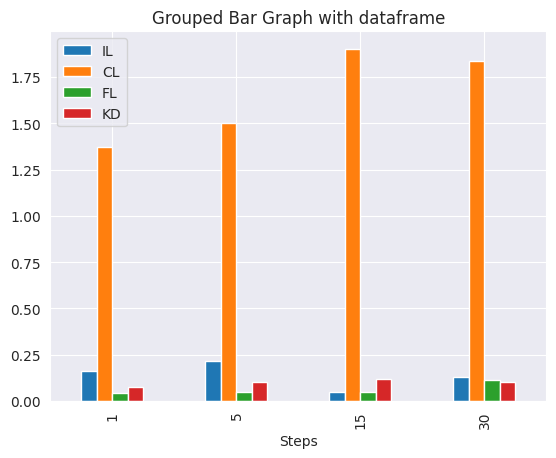

In [4]:
# create data 
model = 'lstm'
metric = 'unscaled_mae'
data_for_df = []
for step in sorted(np.unique(results['step'])):
    isolated = np.mean(results[(results['approach'] == 'Isolated') & (results['step'] == step) & (results['model'] == model)][f'{metric}_avg'])/1000
    centralized = results[(results['approach'] == 'Centralized') & (results['step'] == step) & (results['model'] == model)][f'{metric}_avg'].item()/1000
    fl = results[(results['approach'] == 'FedAvg') & (results['step'] == step) & (results['model'] == model)][f'{metric}_avg'].item()/1000
    kd = results[(results['approach'] == 'FedGen') & (results['step'] == step) & (results['model'] == model)][f'{metric}_avg'].item()/1000
    data_for_df.append([step, isolated, centralized, fl, kd])

df = pd.DataFrame(data_for_df, columns=['Steps', 'IL', 'CL', 'FL', 'KD'])

# plot grouped bar chart 
df.plot(x='Steps', 
        kind='bar', 
        stacked=False, 
        title='Grouped Bar Graph with dataframe') 

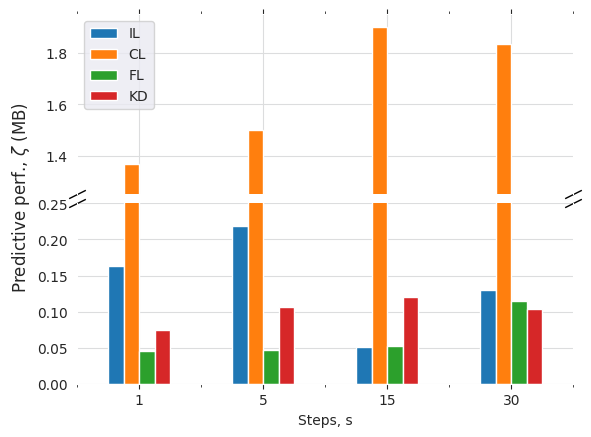

In [11]:
matplotlib.rcParams['grid.color'] = '#dcddde'
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.set_facecolor((1, 1, 1))
ax2.set_facecolor((1, 1, 1))
fig.subplots_adjust(hspace=0.05)  # adjust space between axes
fig.supylabel('Predictive perf., $\zeta$ (MB)')
df.plot(x='Steps',
        kind='bar', 
        stacked=False, 
        ax=ax1,
        rot=0) 

df.plot(x='Steps', 
        kind='bar', 
        stacked=False,
        legend=False,
        ax=ax2,
        rot=0)

ax2.set_xlabel('Steps, s')

ax1.set_ylim(1.25, 1.95)  # outliers only
ax2.set_ylim(0, 0.250)  # most of the data

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

plt.savefig('approach_comparison_lstm.pdf', bbox_inches='tight')

In [12]:
saved_result_path = saved_results_path.format(
                        lookback=60,
                        steps=15,
                        approach='FedAvg',
                        model='lstm',
                        rep=0
                    )
saved_result_path = path.join(saved_result_path, '*.pkl')
if len(glob.glob(saved_result_path)) == 0:
    print(saved_result_path)
saved_result_path = glob.glob(saved_result_path)[0]
with open(saved_result_path, 'rb') as f:
    x = pickle.load(f)
    metrics = x['glob_test_metric'][:5]

In [13]:
sorted(metrics, key=lambda x: x['mae'], reverse=True)

[{'mse': 0.17138888173726977,
  'mae': 0.4019759937957521,
  'mape': 0.3051980939251735,
  'unscaled_mse': 21840.024081134252,
  'unscaled_mae': 47.05270519926047,
  'unscaled_mape': 100475487.62594813},
 {'mse': 0.22930026401592232,
  'mae': 0.3357914607606398,
  'mape': 0.31802324160652784,
  'unscaled_mse': 21415.4953005595,
  'unscaled_mae': 46.05030508637289,
  'unscaled_mape': 2314972234297.6685},
 {'mse': 0.18077087576908094,
  'mae': 0.30473822757192015,
  'mape': 0.28429401157616574,
  'unscaled_mse': 19631.67138046169,
  'unscaled_mae': 73.63009425271746,
  'unscaled_mape': 43322537180219.56},
 {'mse': 0.07194848788210693,
  'mae': 0.18005173312119255,
  'mape': 0.15881155320938223,
  'unscaled_mse': 17616.729903742013,
  'unscaled_mae': 48.951781355408826,
  'unscaled_mape': 12807571668423.893},
 {'mse': 0.06361165337590144,
  'mae': 0.16638264671576936,
  'mape': 0.1439941062559636,
  'unscaled_mse': 18422.17370711678,
  'unscaled_mae': 43.087480156233866,
  'unscaled_mape'